# Proyek Analisis Data: [Brazilian E-Commerce Public Dataset by Olist]
- **Nama:** [Nanda Dwi Arinda]
- **Email:** [arindanandadwi@gmail.com]
- **ID Dicoding:** [CDCC351D6X1260]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah order dari waktu ke waktu?
- Kota mana yang memiliki jumlah customer terbanyak?

## Import Semua Packages/Library yang Digunakan

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from google.colab import files
uploaded = files.upload()

Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv
Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv


## Data Wrangling

### Gathering Data

In [29]:
customers = pd.read_csv('olist_customers_dataset.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [30]:
orders = pd.read_csv('olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Data customer menunjukkan bahwa sebagian besar pelanggan berasal dari kota dan state tertentu (misalnya banyak dari SP), yang mengindikasikan bahwa aktivitas transaksi cenderung terpusat di wilayah tersebut.
- Pada data orders terlihat bahwa mayoritas status pesanan adalah delivered, yang menunjukkan bahwa proses pemesanan hingga pengiriman berjalan dengan baik dan tingkat keberhasilan transaksi cukup tinggi.

### Assessing Data

In [31]:
customers_df.info()
orders_df.info()

customers_df.isnull().sum()
orders_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- Data pada kedua dataset memiliki jumlah baris yang sama dan tidak terdapat missing value pada kolom utama seperti customer_id dan order_id, sehingga data siap untuk digabungkan.
- Terdapat beberapa missing value pada kolom terkait pengiriman, yang kemungkinan disebabkan oleh proses order yang belum selesai atau status tertentu dalam transaksi.

### Cleaning Data

In [32]:
orders = orders.drop(columns=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

In [33]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_estimated_delivery_date  99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


**Insight:**
- Beberapa kolom yang tidak digunakan dalam analisis telah dihapus sehingga dataset menjadi lebih sederhana dan lebih fokus pada informasi utama seperti status order dan waktu pembelian.
- Seluruh data pada kolom yang tersisa tidak memiliki missing value, sehingga data sudah bersih dan siap digunakan untuk analisis lebih lanjut tanpa perlu penanganan tambahan.

### Merge Data

In [34]:
customers = pd.read_csv('olist_customers_dataset.csv')

# merge dengan orders yang sudah kamu cleaning
df = pd.merge(orders, customers, on='customer_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [35]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_estimated_delivery_date  99441 non-null  object
 5   customer_unique_id             99441 non-null  object
 6   customer_zip_code_prefix       99441 non-null  int64 
 7   customer_city                  99441 non-null  object
 8   customer_state                 99441 non-null  object
dtypes: int64(1), object(8)
memory usage: 6.8+ MB


(99441, 9)

In [36]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 5   customer_unique_id             99441 non-null  object        
 6   customer_zip_code_prefix       99441 non-null  int64         
 7   customer_city                  99441 non-null  object        
 8   customer_state                 99441 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 6.8+ MB


In [45]:
df.to_csv("main_data.csv", index=False)

In [46]:
from google.colab import files

files.download("main_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exploratory Data Analysis (EDA)

### Explore ...

In [38]:
# membuat kolom bulan dari tanggal pembelian
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

# menghitung jumlah order per bulan
monthly_orders = df.groupby('month')['order_id'].nunique()

monthly_orders.head()

,order_id
month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780


**Insight:**
- Data menunjukkan bahwa jumlah order dapat dianalisis berdasarkan waktu dengan menggunakan kolom timestamp.
- Terlihat adanya variasi jumlah transaksi pada setiap bulan yang menunjukkan pola tertentu dalam aktivitas pembelian.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

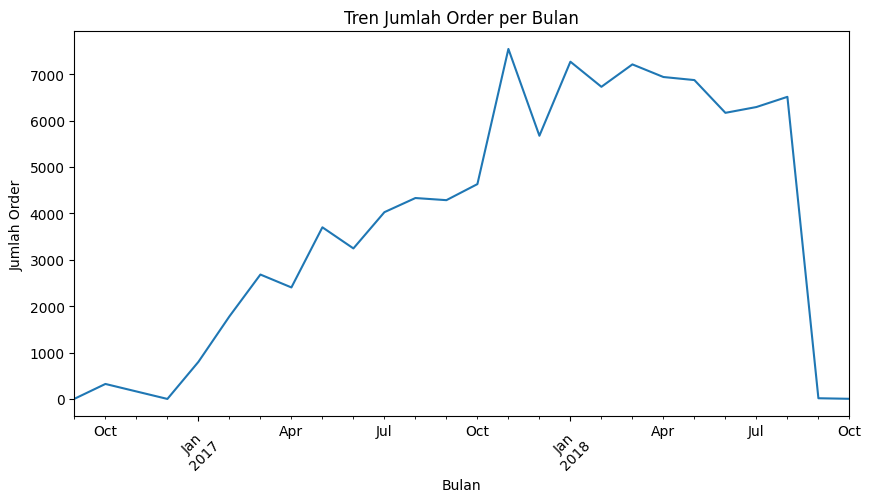

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_orders.plot()
plt.title('Tren Jumlah Order per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

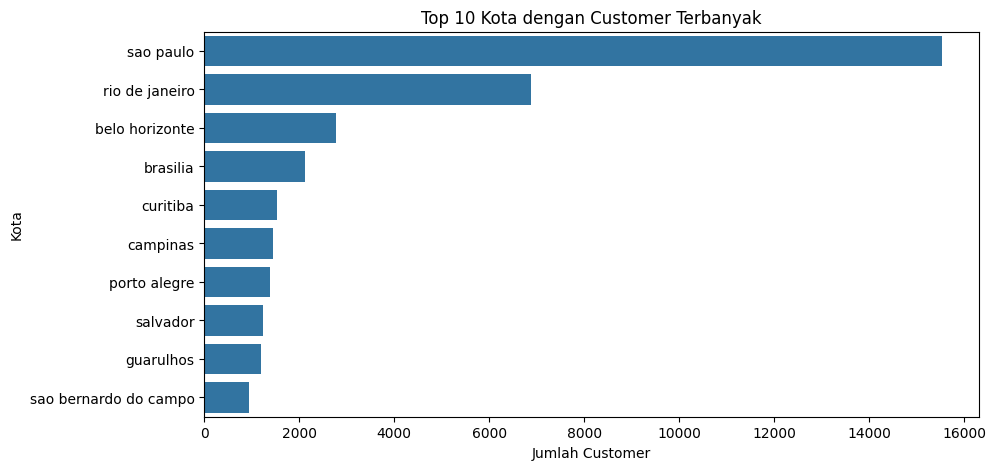

In [40]:
import seaborn as sns

top_city = df['customer_city'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_city.values, y=top_city.index)
plt.title('Top 10 Kota dengan Customer Terbanyak')
plt.xlabel('Jumlah Customer')
plt.ylabel('Kota')
plt.show()

**Insight:**
- Jumlah order menunjukkan peningkatan dari waktu ke waktu, terutama setelah tahun 2017, yang menandakan adanya pertumbuhan aktivitas transaksi pada platform.
- Aktivitas transaksi cenderung terkonsentrasi di beberapa kota dengan jumlah customer yang lebih tinggi, sehingga wilayah tersebut menjadi kontributor utama dalam peningkatan jumlah order.

### RFM


In [48]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

snapshot_date = df['order_purchase_timestamp'].max()

In [49]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique'
})

In [51]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency']

rfm.head()

,customer_id,recency,frequency
0,00012a2ce6f8dcda20d059ce98491703,337,1
1,000161a058600d5901f007fab4c27140,458,1
2,0001fd6190edaaf884bcaf3d49edf079,596,1
3,0002414f95344307404f0ace7a26f1d5,427,1
4,000379cdec625522490c315e70c7a9fb,198,1


## Analisis Lanjutan (Opsional)

In [41]:
order_status = df['order_status'].value_counts()

order_status

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


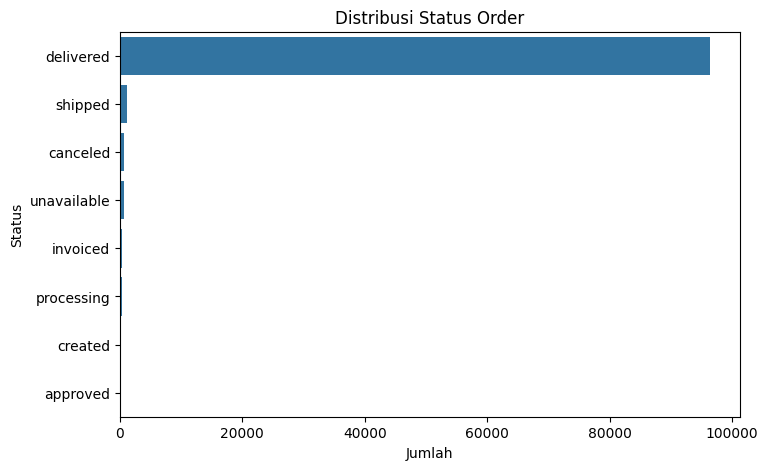

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=order_status.values, y=order_status.index)
plt.title('Distribusi Status Order')
plt.xlabel('Jumlah')
plt.ylabel('Status')
plt.show()

## Conclusion

- Pertanyaan 1:
Tren jumlah order menunjukkan adanya kenaikan dan penurunan pada periode tertentu, yang mengindikasikan pola pembelian yang dinamis.
- Pertanyaan 2:
Customer terbanyak berasal dari beberapa kota tertentu, sehingga wilayah tersebut berpotensi menjadi fokus utama dalam strategi pemasaran.